# 🤖 LLM4Teach — PPO Training Notebook
### Train with and without LLM teacher · Windows CPU/GPU · Qwen-powered

| Mode | Teacher | Kickstarting | Needs API? | Speed |
|------|---------|:------------:|:----------:|-------|
| **1 — Pure PPO** | ❌ None | Off | ❌ No | Fastest |
| **2 — Offline Teacher** | ✅ Pre-computed plans | On | ❌ No | Fast |
| **3 — Online Qwen** | ✅ Real Qwen LLM calls | On | ⚠️ Optional | Slower |

**Qwen API key?**
- Mode 1 & 2: **No key needed at all**
- Mode 3 with Ollama: **No key needed** (local model)
- Mode 3 with Dashscope: **Free key** from https://bailian.console.aliyun.com/

In [1]:
# ── Cell 1: Install packages ──────────────────────────────────────────
import sys, subprocess
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "torch", "gymnasium==1.3.0", "minigrid==3.1.0",
    "tensorboard", "opencv-python", "matplotlib", "ipywidgets",
    "--quiet"
], check=False)
print("✅ Packages ready")

✅ Packages ready


In [2]:
# ── Cell 2: Repo setup + imports ──────────────────────────────────────
import sys, os, warnings, time, json
warnings.filterwarnings("ignore")

REPO = r"C:\Users\HP\Downloads\LLM4Teach-main (1)\LLM4Teach-main"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
os.chdir(REPO)

# Force-reload all project modules (safe to re-run)
for _m in list(sys.modules.keys()):
    if any(x in _m for x in ["Game","algos","skill","env","mediator",
                               "teacher","planner","utils"]):
        del sys.modules[_m]

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
from types import SimpleNamespace

from Game import Game
from utils.qwen_llm import QwenLLM

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {'CUDA (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")
import gymnasium; print(f"Gym     : {gymnasium.__version__}")
import minigrid;  print(f"MiniGrid: {minigrid.__version__}")
print()
print("✅ All imports OK")

Python  : 3.11.15
PyTorch : 2.11.0+cpu
Device  : CPU
Gym     : 1.3.0
MiniGrid: 3.1.0

✅ All imports OK


In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║              ⚙️  CONFIGURATION  —  EDIT THIS CELL              ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Task ─────────────────────────────────────────────────────────────
# Options: "SimpleDoorKey" | "LavaDoorKey" | "ColoredDoorKey" | "TwoDoor"
TASK = "SimpleDoorKey"

# ── Device ───────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Training iterations ───────────────────────────────────────────────
# Sanity check: 5   |  Quick demo: 300  |  Full paper: 20000
N_ITR          = 5

# ── Trajectories per iteration ───────────────────────────────────────
TRAJ_PER_ITR   = 1

# ── Batch size ───────────────────────────────────────────────────────
BATCH_SIZE     = 64

# ── Evaluate agent every N iterations ───────────────────────────────
EVAL_INTERVAL  = 10

# ── Redraw live plot every N iterations ──────────────────────────────
PLOT_EVERY     = 10

# ── Seed ─────────────────────────────────────────────────────────────
SEED           = 42

# ── Qwen backend (only for Mode 3) ───────────────────────────────────
# 'offline'   → no real LLM calls, uses same pre-computed plans as Mode 2
# 'ollama'    → local Qwen2.5 via Ollama, NO API KEY needed
#               Install: https://ollama.ai  then: ollama pull qwen2.5:1.5b
# 'dashscope' → Alibaba Cloud API, FREE tier available
#               Key at: https://bailian.console.aliyun.com/
QWEN_BACKEND   = "ollama"        # ← change me
QWEN_API_KEY   = None             # ← paste key here if using dashscope
QWEN_MODEL     = "qwen2.5:1.5b"   # ollama model name

print(f"Task     : {TASK}")
print(f"Device   : {DEVICE}")
print(f"N_itr    : {N_ITR}")
print(f"Qwen     : {QWEN_BACKEND}")

Task     : SimpleDoorKey
Device   : cpu
N_itr    : 5
Qwen     : ollama


In [4]:
# ── Cell 4: Helper functions ──────────────────────────────────────────

def make_args(savedir, n_itr=N_ITR, traj_per_itr=TRAJ_PER_ITR,
              batch_size=BATCH_SIZE, offline_planner=True, seed=SEED):
    """Build a SimpleNamespace args object."""
    return SimpleNamespace(
        seed=seed, task=TASK, frame_stack=1,
        offline_planner=offline_planner, soft_planner=False,
        logdir="log", policy="ppo",
        loaddir=None, loadmodel="acmodel",
        savedir=savedir,
        device=DEVICE,
        batch_size=batch_size,
        recurrent=False, gamma=0.99, lam=0.95,
        n_itr=n_itr, traj_per_itr=traj_per_itr,
        num_eval=5, eval_interval=EVAL_INTERVAL, save_interval=500,
    )


def train_and_track(game, n_itr, label="run",
                    eval_interval=EVAL_INTERVAL,
                    eval_episodes=3,
                    plot_every=PLOT_EVERY,
                    verbose=True):
    """
    Training loop with live metric tracking.
    Mirrors Game.train() without modifying it.

    Returns
    -------
    history : dict  — recorded metrics for plotting
    """
    history = dict(
        itr=[], success_rate=[], avg_return=[],
        avg_ep_len=[], ks_coef=[], total_steps=[],
        eval_itr=[], eval_success=[], eval_return=[],
    )
    start = time.time()

    for itr in range(n_itr):
        # ── collect ──────────────────────────────────────────────────
        game.buffer.clear()
        n_traj = game.traj_per_itr
        for _ in range(n_traj):
            game.collect()
        while len(game.buffer) < game.batch_size * 2:
            game.collect()
            n_traj += 1
        game.total_steps += len(game.buffer)

        # ── update ───────────────────────────────────────────────────
        mean_losses = game.student_policy.update_policy(game.buffer)

        # ── train metrics ─────────────────────────────────────────────
        avg_ret = float(np.mean(game.buffer.ep_returns))
        avg_len = float(np.mean(game.buffer.ep_lens))
        success = sum(r > 0 for r in game.buffer.ep_returns) / n_traj
        ks      = game.student_policy.ks_coef

        history["itr"].append(itr)
        history["success_rate"].append(success)
        history["avg_return"].append(avg_ret)
        history["avg_ep_len"].append(avg_len)
        history["ks_coef"].append(ks)
        history["total_steps"].append(game.total_steps)

        # ── eval ─────────────────────────────────────────────────────
        if itr % eval_interval == 0 and itr > 0:
            res = [game.evaluate(record_frames=False)
                   for _ in range(eval_episodes)]
            history["eval_itr"].append(itr)
            history["eval_success"].append(
                float(np.mean([r[2] for r in res])))
            history["eval_return"].append(
                float(np.mean([r[0] for r in res])))

        # ── console log ───────────────────────────────────────────────
        if verbose and (itr % 10 == 0 or itr == n_itr - 1):
            elapsed = time.time() - start
            target_status = (
                "\033[92m✅ REACHING TARGET\033[0m"
                if success > 0
                else "\033[91m❌ not reaching target\033[0m"
            )
            print(
                f"[{label}] [{itr:4d}/{n_itr}] "
                f"ret={avg_ret:6.3f} | "
                f"succ={success:.2f} | "
                f"len={avg_len:5.1f} | "
                f"ks={ks:.3f} | "
                f"steps={game.total_steps:,} | "
                f"{target_status} | {elapsed:.0f}s"
            )

        # ── live plot ─────────────────────────────────────────────────
        if itr % plot_every == 0 and itr > 1:
            _live_plot(history, label=label, itr=itr, n_itr=n_itr)

    game.student_policy.save()
    final_s = np.mean(history["success_rate"][-20:])
    print(f"\n[{label}] ✅ Training complete. "
          f"Steps={game.total_steps:,} | "
          f"Final success rate (last 20 itr avg)={final_s:.3f}")
    return history


def _live_plot(history, label="", itr=0, n_itr=1):
    """Redraw training charts inline."""
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    itrs = history["itr"]

    # Success rate
    ax = axes[0]
    ax.plot(itrs, history["success_rate"], "g-", lw=2, label="Train")
    if history["eval_itr"]:
        ax.plot(history["eval_itr"], history["eval_success"],
                "g^", ls="--", lw=2, ms=8, label="Eval")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_title("✅ Is agent reaching the target?", fontsize=11)
    ax.set_xlabel("Iteration"); ax.set_ylabel("Success Rate")
    ax.set_ylim(-0.05, 1.05); ax.legend(); ax.grid(alpha=0.3)

    # Return
    ax = axes[1]
    ax.plot(itrs, history["avg_return"], "b-", lw=2, label="Train")
    if history["eval_itr"]:
        ax.plot(history["eval_itr"], history["eval_return"],
                "b^", ls="--", lw=2, ms=8, label="Eval")
    ax.set_title("Average Return", fontsize=11)
    ax.set_xlabel("Iteration"); ax.legend(); ax.grid(alpha=0.3)

    # Episode length
    ax = axes[2]
    ax.plot(itrs, history["avg_ep_len"], color="orange", lw=2)
    ax.set_title("Episode Length  (lower = faster to goal)", fontsize=11)
    ax.set_xlabel("Iteration"); ax.grid(alpha=0.3)

    pct = int(100 * itr / max(n_itr, 1))
    plt.suptitle(f"{label}  —  Iteration {itr}/{n_itr}  ({pct}%)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"plot_{label.replace(' ', '_').replace('/', '_')}.png"
    plt.savefig(fname, dpi=80, bbox_inches="tight")
    plt.show()


def final_comparison(histories, labels, save="comparison.png"):
    """Side-by-side comparison chart for all runs."""
    colors = ["#e74c3c", "#2ecc71", "#3498db", "#9b59b6"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    def smooth(x, w=15):
        w = min(w, len(x))
        return np.convolve(x, np.ones(w) / w, mode="valid"), w

    for h, label, c in zip(histories, labels, colors):
        sr, w = smooth(h["success_rate"])
        rt, _ = smooth(h["avg_return"], w)
        xs = h["itr"][w - 1:]
        axes[0].plot(xs, sr, color=c, lw=2.5, label=label)
        axes[1].plot(xs, rt, color=c, lw=2.5, label=label)

    axes[0].set_title(
        "Success Rate  —  Is the agent reaching the target?", fontsize=12)
    axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Success Rate")
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].axhline(0, color="gray", ls="--", alpha=0.4)
    axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

    axes[1].set_title("Return Comparison", fontsize=12)
    axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Return")
    axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

    plt.suptitle(
        f"LLM4Teach on {TASK}  —  {N_ITR} iterations  [{DEVICE.upper()}]",
        fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"Chart saved → {save}")

    # Summary table
    print()
    print("=" * 62)
    print(f"{'Mode':<32} {'SuccessRate':>12} {'AvgReturn':>12}")
    print("=" * 62)
    for h, label in zip(histories, labels):
        tail = 20
        last_s = float(np.mean(h["success_rate"][-tail:]))
        last_r = float(np.mean(h["avg_return"][-tail:]))
        icon   = "✅" if last_s > 0.05 else "❌"
        print(f"{icon} {label:<30} {last_s:>12.3f} {last_r:>12.3f}")
    print("=" * 62)


print("✅ Helper functions loaded")

✅ Helper functions loaded


In [5]:
# ── Cell 5: 🔬 Sanity Test (< 60 seconds) ────────────────────────────
print("Running quick 3-iteration sanity test ...\n")
_a = make_args("sanity_test", n_itr=3, traj_per_itr=1)
_g = Game(_a)

t_out = _g.evaluate(teacher_policy=True,  record_frames=False, deterministic=False)
s_out = _g.evaluate(teacher_policy=False, record_frames=False, deterministic=False)
_g.collect()
_h = train_and_track(_g, 3, label="sanity", plot_every=9999, verbose=True)

print()
print(f"  Teacher eval → return={t_out[0]:.3f}  len={t_out[1]}  success={t_out[2]}")
print(f"  Student eval → return={s_out[0]:.3f}  len={s_out[1]}  success={s_out[2]}")
print(f"  Buffer steps → {len(_g.buffer)}")
print()
print("✅ SANITY TEST PASSED — ready to train!")

Running quick 3-iteration sanity test ...

[INFO]: resetting the task: SimpleDoorKey
Logging to log\ppo\SimpleDoorKey\sanity_test
use MLP......
[sanity] [   0/3] ret= 0.000 | succ=0.00 | len=150.0 | ks=9.995 | steps=150 | ❌ not reaching target | 0s
[sanity] [   2/3] ret= 0.000 | succ=0.00 | len=150.0 | ks=9.985 | steps=450 | ❌ not reaching target | 1s

[sanity] ✅ Training complete. Steps=450 | Final success rate (last 20 itr avg)=0.000

  Teacher eval → return=0.808  len=32  success=1
  Student eval → return=0.000  len=150  success=0
  Buffer steps → 150

✅ SANITY TEST PASSED — ready to train!


---
## 🤖 Mode 1 — Pure PPO (no LLM teacher)

Standard PPO with **no teacher signal**.  
Achieved by setting `iter_with_ks = 0` so the kickstarting loss is never added.  
The agent learns purely from environment rewards.

> **Expected**: slower learning, lower success rate at same iteration count.

In [6]:
# ── Cell 6: Train Mode 1 — Pure PPO ──────────────────────────────────
args1 = make_args("mode1_pure_ppo", n_itr=N_ITR)
game1 = Game(args1)

# Disable kickstarting: iter_with_ks=0 means condition
# (self.iter < self.iter_with_ks) is always False → ks term never added
game1.student_policy.iter_with_ks = 0

print("Mode 1: Pure PPO")
print(f"  iter_with_ks  = {game1.student_policy.iter_with_ks}  → kickstarting DISABLED")
print(f"  ks_coef       = {game1.student_policy.ks_coef}  (irrelevant, never applied)")
print()

history1 = train_and_track(
    game1, N_ITR,
    label="Pure PPO",
    eval_interval=EVAL_INTERVAL,
    plot_every=PLOT_EVERY,
)

[INFO]: resetting the task: SimpleDoorKey
Logging to log\ppo\SimpleDoorKey\mode1_pure_ppo
use MLP......
Mode 1: Pure PPO
  iter_with_ks  = 0  → kickstarting DISABLED
  ks_coef       = 10.0  (irrelevant, never applied)

[Pure PPO] [   0/5] ret= 0.000 | succ=0.00 | len=150.0 | ks=10.000 | steps=150 | ❌ not reaching target | 0s
[Pure PPO] [   4/5] ret= 0.000 | succ=0.00 | len=150.0 | ks=10.000 | steps=750 | ❌ not reaching target | 2s

[Pure PPO] ✅ Training complete. Steps=750 | Final success rate (last 20 itr avg)=0.000


---
## 🎓 Mode 2 — PPO + Offline LLM Teacher

PPO guided by a **pre-computed LLM teacher** (no API calls needed).  
Plans are baked into `planner.py` dicts based on what GPT-4 answered offline.  
The teacher guides the student via the **kickstarting loss** (decays over time).

> **Expected**: faster learning, higher early success rate.

In [7]:
# ── Cell 7: Train Mode 2 — PPO + Offline Teacher ─────────────────────
args2 = make_args("mode2_offline_teacher", n_itr=N_ITR, offline_planner=True)
game2 = Game(args2)

print("Mode 2: PPO + Offline LLM Teacher")
print(f"  iter_with_ks  = {game2.student_policy.iter_with_ks}  iterations")
print(f"  ks_coef start = {game2.student_policy.ks_coef}")
print(f"  ks_coef min   = {game2.student_policy.ks_coef_minimum}")
print(f"  ks_coef decay = {game2.student_policy.ks_coef_descent} per iter")
print()

history2 = train_and_track(
    game2, N_ITR,
    label="Offline Teacher",
    eval_interval=EVAL_INTERVAL,
    plot_every=PLOT_EVERY,
)

[INFO]: resetting the task: SimpleDoorKey
Logging to log\ppo\SimpleDoorKey\mode2_offline_teacher
use MLP......
Mode 2: PPO + Offline LLM Teacher
  iter_with_ks  = 3000  iterations
  ks_coef start = 10.0
  ks_coef min   = 0.1
  ks_coef decay = 0.005 per iter

[Offline Teacher] [   0/5] ret= 0.000 | succ=0.00 | len=150.0 | ks=9.995 | steps=150 | ❌ not reaching target | 0s
[Offline Teacher] [   4/5] ret= 0.000 | succ=0.00 | len=150.0 | ks=9.975 | steps=750 | ❌ not reaching target | 2s

[Offline Teacher] ✅ Training complete. Steps=750 | Final success rate (last 20 itr avg)=0.000


---
## 🌐 Mode 3 — PPO + Online Qwen LLM

The teacher queries a **real Qwen model** at runtime.  
Two free options — no OpenAI account needed.

### API Key?
| Backend | Key needed | Setup |
|---------|:----------:|-------|
| `offline` | ❌ No | Nothing |
| `ollama` | ❌ No | Install Ollama + pull qwen2.5:1.5b |
| `dashscope` | ✅ Free | Sign up at bailian.console.aliyun.com |

In [8]:
# ── Cell 8: Qwen setup check ──────────────────────────────────────────
QwenLLM.api_key_guide()
QWEN_BACKEND == "ollama"
_qwen_ok = False
_use_qwen_backend = QWEN_BACKEND

if QWEN_BACKEND == "offline":
    print("ℹ️  QWEN_BACKEND='offline' → Mode 3 uses same pre-computed plans as Mode 2")
    print("   Set QWEN_BACKEND='ollama' or 'dashscope' in config cell for real LLM calls")
    _qwen_ok = True

elif QWEN_BACKEND == "ollama":
    _qwen = QwenLLM(backend="ollama", model=QWEN_MODEL)
    # Quick connectivity test
    try:
        _resp = _qwen.call(
            system_prompt="You are a brief planning assistant.",
            user_prompt="Agent sees <key>, holds <nothing>.\nRespond with Action: {plan}"
        )
        _plan = QwenLLM.parse_plan(_resp)
        print(f"\n✅ Ollama Qwen test OK!")
        print(f"   Response: {_resp[:180]}")
        print(f"   Parsed plan: {_plan}")
        _qwen_ok = True
    except Exception as _e:
        print(f"\n❌ Ollama test failed: {_e}")
        print("   → Falling back to offline mode for Mode 3")
        _use_qwen_backend = "offline"

elif QWEN_BACKEND == "dashscope":
    if not QWEN_API_KEY:
        print("❌ QWEN_API_KEY is not set!")
        print("   Get a free key at https://bailian.console.aliyun.com/")
        print("   Set QWEN_API_KEY = 'sk-...' in the config cell")
        _use_qwen_backend = "offline"
    else:
        try:
            _qwen = QwenLLM(backend="dashscope", api_key=QWEN_API_KEY)
            _resp = _qwen.call(
                system_prompt="You are a brief planning assistant.",
                user_prompt="Agent sees <key>, holds <nothing>.\nRespond with Action: {plan}"
            )
            _plan = QwenLLM.parse_plan(_resp)
            print(f"\n✅ Dashscope Qwen test OK!")
            print(f"   Response: {_resp[:180]}")
            print(f"   Parsed plan: {_plan}")
            _qwen_ok = True
        except Exception as _e:
            print(f"\n❌ Dashscope test failed: {_e}")
            _use_qwen_backend = "offline"

print(f"\n→ Mode 3 will use backend: '{_use_qwen_backend}'")


╔══════════════════════════════════════════════════════════╗
║              QWEN LLM  —  SETUP GUIDE                   ║
╠══════════════════════════════════════════════════════════╣
║  OPTION A  offline  (default, zero setup)               ║
║    Pre-computed plans, no internet, no key.             ║
║    Set: args.offline_planner = True                     ║
╠══════════════════════════════════════════════════════════╣
║  OPTION B  ollama   (local model, NO key needed)        ║
║    1. Install  →  https://ollama.ai                     ║
║    2. Pull     →  ollama pull qwen2.5:1.5b              ║
║    3. Start    →  ollama serve                          ║
║    Use: QwenLLM(backend='ollama')                       ║
╠══════════════════════════════════════════════════════════╣
║  OPTION C  dashscope  (Alibaba Cloud, free tier)        ║
║    1. Sign up  →  https://bailian.console.aliyun.com/   ║
║    2. Create API key  (free 2M tokens/month)            ║
║    3. pip install dashscope      

In [9]:
# ── Cell 9: Train Mode 3 — PPO + Qwen ────────────────────────────────
args3 = make_args(
    "mode3_qwen", n_itr=N_ITR,
    offline_planner=(_use_qwen_backend == "offline")  # True if no real LLM
)
game3 = Game(args3)

# Plug in Qwen if a real backend is available
if _use_qwen_backend != "offline" and _qwen_ok:
    _qwen_live = QwenLLM(
        backend=_use_qwen_backend,
        api_key=QWEN_API_KEY if _use_qwen_backend == "dashscope" else None,
        model=QWEN_MODEL,
    )
    game3.teacher_policy.planner.set_llm(_qwen_live)
    print(f"✅ Qwen ({_use_qwen_backend}) plugged into teacher policy")
else:
    print("ℹ️  Running Mode 3 with offline plans (no live Qwen calls)")

print(f"  iter_with_ks = {game3.student_policy.iter_with_ks}")
print(f"  ks_coef      = {game3.student_policy.ks_coef}")
print()

history3 = train_and_track(
    game3, N_ITR,
    label=f"Qwen ({_use_qwen_backend})",
    eval_interval=EVAL_INTERVAL,
    plot_every=PLOT_EVERY,
)

[INFO]: resetting the task: SimpleDoorKey
Logging to log\ppo\SimpleDoorKey\mode3_qwen
use MLP......
[QwenLLM] Ollama ✅  model 'qwen2.5:1.5b' found.
✅ Qwen (ollama) plugged into teacher policy
  iter_with_ks = 3000
  ks_coef      = 10.0

new obs: Agent sees <door>, holds <nothing>.
[Qwen] Raw response: go to <door>; open <door>
[Qwen] Parsed symbolic plan: go to <door>, open <door>
[Qwen] Raw response: open <door>
[Qwen] Parsed symbolic plan: open <door>
[Qwen] Raw response: open <door>
[Qwen] Parsed symbolic plan: open <door>
[Qwen] Raw response: open <door> go to <goal>
[Qwen] Parsed symbolic plan: open <door>, go to <goal>
[Qwen] Raw response: open <door>
[Qwen] Parsed symbolic plan: open <door>
[Qwen] Raw response: go to <door>, open <door>
[Qwen] Parsed symbolic plan: go to <door>, open <door>
[Qwen] Raw response: go to <door>
[Qwen] Parsed symbolic plan: go to <door>
[Qwen] Raw response: go to <door>, open <door>, explore
[Qwen] Parsed symbolic plan: go to <door>, open <door>
[Qwe

---
## 🏆 Final Comparison

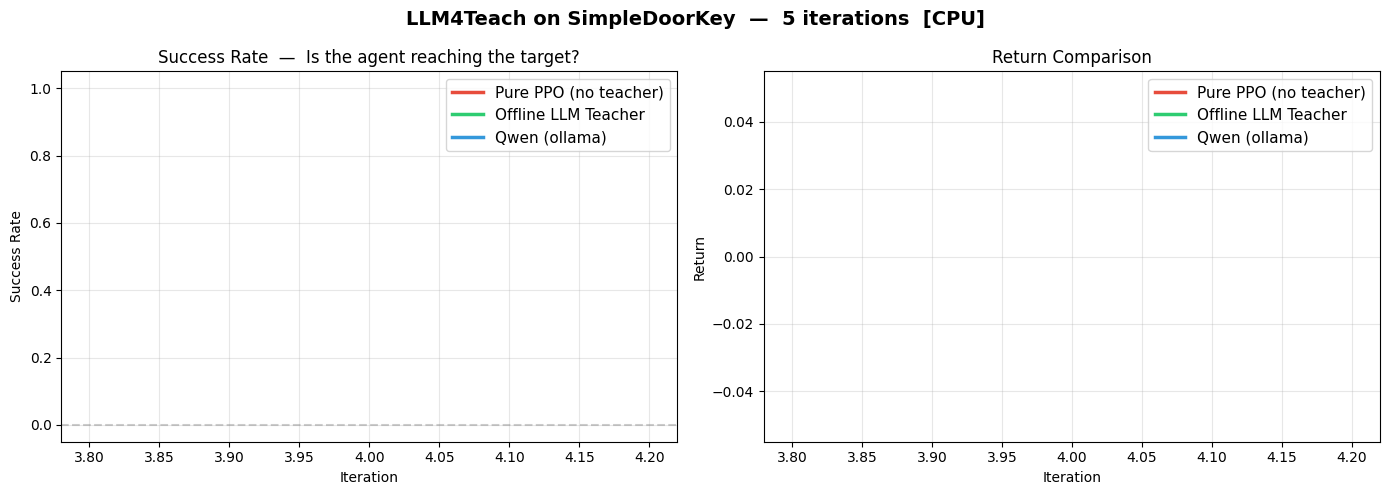

Chart saved → comparison_final.png

Mode                              SuccessRate    AvgReturn
❌ Pure PPO (no teacher)                 0.000        0.000
❌ Offline LLM Teacher                   0.000        0.000
❌ Qwen (ollama)                         0.000        0.000


In [10]:
# ── Cell 10: Comparison chart ─────────────────────────────────────────
final_comparison(
    [history1, history2, history3],
    ["Pure PPO (no teacher)",
     "Offline LLM Teacher",
     f"Qwen ({_use_qwen_backend})"],
    save="comparison_final.png",
)

In [11]:
# ── Cell 11: Detailed evaluation of best model ───────────────────────
# Pick the run with highest success rate
_all = [
    (history1, game1, "Pure PPO"),
    (history2, game2, "Offline Teacher"),
    (history3, game3, f"Qwen ({_use_qwen_backend})"),
]
_best = max(_all, key=lambda x: np.mean(x[0]["success_rate"][-20:]))
_best_h, _best_game, _best_label = _best

print(f"🏆 Best model: {_best_label}")
print(f"   Running 20 evaluation episodes ...")
print()

_eval_results = [_best_game.evaluate(record_frames=False)
                 for _ in range(20)]
_eval_ret  = [r[0] for r in _eval_results]
_eval_len  = [r[1] for r in _eval_results]
_eval_succ = [r[2] for r in _eval_results]

print(f"  Success rate  : {np.mean(_eval_succ):.2f}  ({sum(_eval_succ)}/20 episodes reached target)")
print(f"  Mean return   : {np.mean(_eval_ret):.4f} ± {np.std(_eval_ret):.4f}")
print(f"  Mean ep len   : {np.mean(_eval_len):.1f} steps")
print()

# Also evaluate teacher policy as upper bound
print("Teacher policy (upper bound):")
_teacher_results = [_best_game.evaluate(
    teacher_policy=True, record_frames=False, deterministic=False)
    for _ in range(20)]
_t_succ = [r[2] for r in _teacher_results]
_t_ret  = [r[0] for r in _teacher_results]
print(f"  Success rate  : {np.mean(_t_succ):.2f}")
print(f"  Mean return   : {np.mean(_t_ret):.4f}")
print()

gap = np.mean(_t_succ) - np.mean(_eval_succ)
print(f"  Student vs teacher gap: {gap:.2f} success rate")
if gap < 0.2:
    print("  🌟 Student is close to teacher performance!")
elif gap < 0.5:
    print("  📈 Student is learning — more iterations will close the gap")
else:
    print("  ⏳ More training iterations needed (try N_ITR=2000+)")

🏆 Best model: Pure PPO
   Running 20 evaluation episodes ...

  Success rate  : 0.00  (0/20 episodes reached target)
  Mean return   : 0.0000 ± 0.0000
  Mean ep len   : 150.0 steps

Teacher policy (upper bound):
  Success rate  : 1.00
  Mean return   : 0.8650

  Student vs teacher gap: 1.00 success rate
  ⏳ More training iterations needed (try N_ITR=2000+)


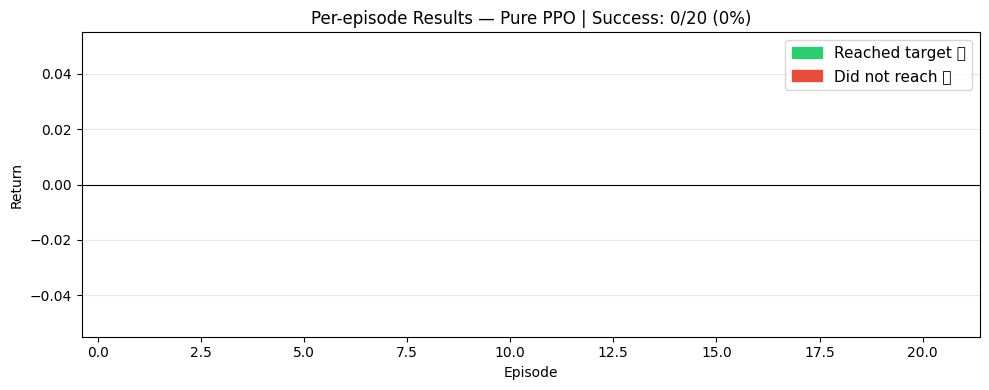

Saved → per_episode_results.png


In [12]:
# ── Cell 12: Episode success bar chart ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

episodes = list(range(1, 21))
colors_bar = ["#2ecc71" if s else "#e74c3c" for s in _eval_succ]
ax.bar(episodes, _eval_ret, color=colors_bar, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", lw=0.8)

from matplotlib.patches import Patch
legend_els = [Patch(color="#2ecc71", label="Reached target ✅"),
              Patch(color="#e74c3c", label="Did not reach ❌")]
ax.legend(handles=legend_els, fontsize=11)
ax.set_title(
    f"Per-episode Results — {_best_label} | "
    f"Success: {sum(_eval_succ)}/20 ({np.mean(_eval_succ)*100:.0f}%)",
    fontsize=12)
ax.set_xlabel("Episode"); ax.set_ylabel("Return")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_episode_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved → per_episode_results.png")

---
## 📖 Quick Reference

### How to start full training from terminal
```bash
cd "C:\Users\HP\Downloads\LLM4Teach-main (1)\LLM4Teach-main"
conda activate gpt_inf

# With offline teacher (recommended for CPU)
python main.py train --task SimpleDoorKey --savedir run1 --offline_planner --n_itr 20000 --traj_per_itr 10

# Pure PPO baseline
python main.py train --task SimpleDoorKey --savedir run_ppo --offline_planner --n_itr 20000
```

### Monitor with TensorBoard
```bash
tensorboard --logdir log
# Then open http://localhost:6006
```

### To make training faster on CPU
```python
import torch
torch.set_num_threads(os.cpu_count())   # use all cores
# Also try: smaller BATCH_SIZE, smaller TRAJ_PER_ITR
```

### Qwen online planning
```python
# Ollama (free, local)
# 1. ollama pull qwen2.5:1.5b
# 2.
from utils.qwen_llm import QwenLLM
qwen = QwenLLM(backend='ollama')
game.teacher_policy.planner.set_llm(qwen)

# Dashscope (free tier, cloud)
qwen = QwenLLM(backend='dashscope', api_key='sk-...')
game.teacher_policy.planner.set_llm(qwen)
```